In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [ ]:
df_CTGAN = pd.read_csv('/content/drive/MyDrive/AQI_Minority_Sampled_GAN.csv')
df_CTGAN.head()

,Unnamed: 0,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name,local_time,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos,AQI_Value,AQI_Confidence,AQI_Category
0,0,2016-02-09 20:00:00,GB,Haringey,Haringey - Haringey Town Hall,51.587936,-0.105438,10.0,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network,2016-02-09 19:59:35+00:00,19,2,1,0,1,3,10.0,NaN,NaN,NaN,NaN,NaN,-0.965926,0.258819,41.666667,75,Good
1,1,2016-02-09 20:00:00,GB,London,Haringey Roadside,51.507446,-0.127765,10.0,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 19:59:29+00:00,19,2,1,0,1,3,10.0,NaN,NaN,NaN,NaN,NaN,-0.965926,0.258819,41.666667,75,Good
2,2,2016-02-09 21:00:00,GB,London,Haringey Roadside,51.507446,-0.127765,10.0,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 20:59:29+00:00,20,2,1,0,1,3,10.0,NaN,NaN,NaN,NaN,NaN,-0.866025,0.500000,41.666667,75,Good
3,3,2016-02-09 21:00:00,GB,Haringey,Haringey - Haringey Town Hall,51.587936,-0.105438,10.0,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network,2016-02-09 20:59:35+00:00,20,2,1,0,1,3,10.0,NaN,NaN,NaN,NaN,NaN,-0.866025,0.500000,41.666667,75,Good
4,4,2016-02-09 22:00:00,GB,London,Haringey Roadside,51.507446,-0.127765,10.0,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 21:59:29+00:00,21,2,1,0,1,4,10.0,NaN,NaN,NaN,NaN,NaN,-0.707107,0.707107,41.666667,75,Good


In [ ]:
df_CTGAN = df_CTGAN.drop(columns=['Unnamed: 0'])
df_CTGAN = df_CTGAN.sort_values(by=['timestamp'])

In [ ]:
df_CTGAN.shape

(6713708, 32)

In [ ]:
df_CTGAN.columns

Index(['timestamp', 'country', 'region_name', 'station_name', 'latitude',
       'longitude', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
       'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'pollutant_count',
       'source_name', 'local_time', 'local_hour', 'local_month',
       'local_day_of_week', 'is_weekend', 'season', 'time_of_day',
       'PM2.5_24h_mean', 'PM10_24h_mean', 'NO2_24h_mean', 'SO2_24h_mean',
       'O3_24h_mean', 'CO_24h_mean', 'hour_sin', 'hour_cos', 'AQI_Value',
       'AQI_Confidence', 'AQI_Category'],
      dtype='object')

In [ ]:
df_CTGAN.describe()

,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos,AQI_Value,AQI_Confidence
count,6.713708e+06,6.713708e+06,3.341421e+06,3.279563e+06,3.713047e+06,1.973068e+06,3.987805e+06,1.395756e+06,6.713708e+06,6.713708e+06,6.713708e+06,6.713708e+06,6.713708e+06,6.713708e+06,6.713708e+06,3.395935e+06,3.349834e+06,3.804013e+06,2.057477e+06,4.052605e+06,1.429134e+06,6.713708e+06,6.713708e+06,6.713708e+06,6.713708e+06
mean,3.730214e+01,-2.138209e+01,2.043400e+01,4.419794e+01,1.997165e+01,3.179932e+01,6.226361e+01,8.627912e+02,2.635006e+00,1.149077e+01,4.393308e+00,2.976791e+00,2.724450e-01,2.153792e+00,2.667000e+00,2.036711e+01,4.389401e+01,2.009267e+01,3.419355e+01,6.205200e+01,8.630882e+02,2.558545e-03,-1.904742e-03,4.442791e+01,7.128703e+01
std,2.042954e+01,6.265512e+01,5.346231e+01,9.198431e+01,4.956853e+01,1.228952e+02,3.249898e+01,3.101906e+03,1.565537e+00,6.913705e+00,7.521548e-01,1.944299e+00,4.452176e-01,5.245456e-01,1.213126e+00,4.062927e+01,8.073729e+01,4.471858e+01,1.092000e+02,2.383113e+01,1.888986e+03,7.069979e-01,7.072085e-01,5.618890e+01,2.181008e+01
min,-5.316257e+01,-1.617670e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,3.900000e+01
25%,3.545819e+01,-8.185360e+01,4.416000e+00,1.137667e+01,5.957143e+00,1.700000e+00,4.310000e+01,2.012500e+02,1.000000e+00,6.000000e+00,4.000000e+00,1.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,4.664912e+00,1.204924e+01,6.663895e+00,1.799948e+00,4.760417e+01,2.106704e+02,-7.071068e-01,-7.071068e-01,1.898148e+01,4.400000e+01
50%,4.262323e+01,1.241650e+00,8.091666e+00,1.840750e+01,1.153333e+01,3.700000e+00,6.272000e+01,3.435000e+02,2.000000e+00,1.100000e+01,4.000000e+00,3.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,8.293750e+00,1.883160e+01,1.237202e+01,3.937500e+00,6.378167e+01,3.563017e+02,1.224647e-16,-1.836970e-16,3.218809e+01,7.800000e+01
75%,4.864584e+01,1.541660e+01,1.598462e+01,3.296250e+01,2.147350e+01,1.171606e+01,7.938000e+01,6.579021e+02,4.000000e+00,1.700000e+01,5.000000e+00,5.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,1.583333e+01,3.275000e+01,2.224261e+01,1.309333e+01,7.714584e+01,7.287448e+02,7.071068e-01,7.071068e-01,4.621212e+01,8.900000e+01
max,7.890669e+01,1.530870e+02,1.152807e+03,1.131735e+03,1.327902e+03,1.154301e+03,7.704293e+02,6.166537e+04,6.000000e+00,2.300000e+01,1.200000e+01,6.000000e+00,1.000000e+00,4.000000e+00,4.000000e+00,1.049823e+03,1.017192e+03,1.192382e+03,1.113550e+03,5.675833e+02,5.698086e+04,1.000000e+00,1.000000e+00,5.000000e+02,1.010000e+02


EXPLORATORY DATA ANALYSIS

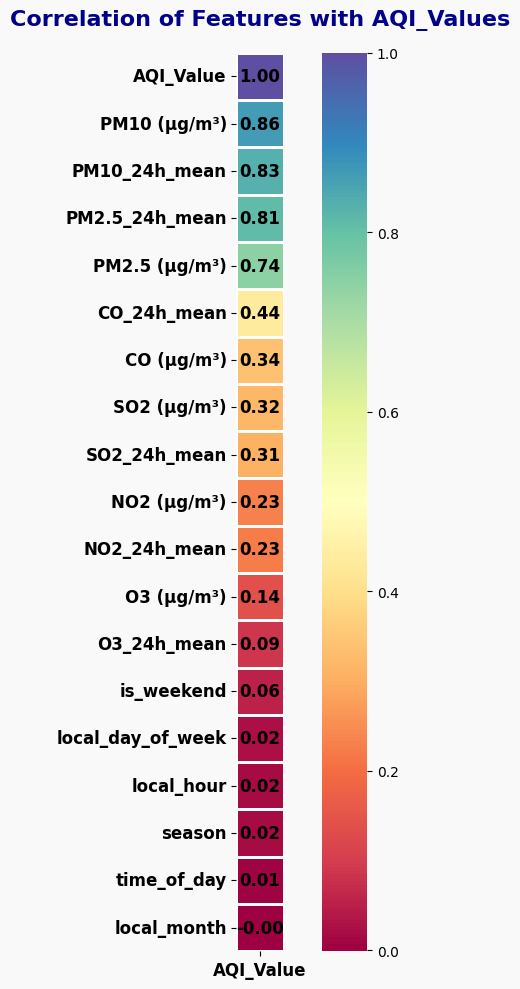

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Select only numeric columns relevant to pollution
numeric_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
                'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'local_hour', 'local_month',
                'local_day_of_week', 'is_weekend', 'season', 'time_of_day', 'AQI_Value','PM2.5_24h_mean', 'PM10_24h_mean', 'NO2_24h_mean', 'SO2_24h_mean',
                'O3_24h_mean', 'CO_24h_mean', ]

# Correlation with dependent variable (CCME_Values)
corr = df_CTGAN[numeric_cols].corr()['AQI_Value'].sort_values(ascending=False)

# Plot heatmap
plt.figure(figsize=(8, 10), facecolor="#f9f9f9")

sns.heatmap(
    corr.to_frame(),
    annot=True,
    cmap="Spectral",
    cbar=True,
    fmt=".2f",
    annot_kws={"size": 12, "weight": "bold", "color": "black"},
    linewidths=0.8,
    linecolor="white",
    square=True
)

# Titles and labels styling
plt.title(
    "Correlation of Features with AQI_Values",
    fontsize=16,
    fontweight="bold",
    color="darkblue",
    pad=20
)

plt.xticks(fontsize=12, weight="bold", color="black")
plt.yticks(fontsize=12, weight="bold", color="black", rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipython-input-1576637279.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df_CTGAN.groupby('AQI_Category', observed=True).apply(


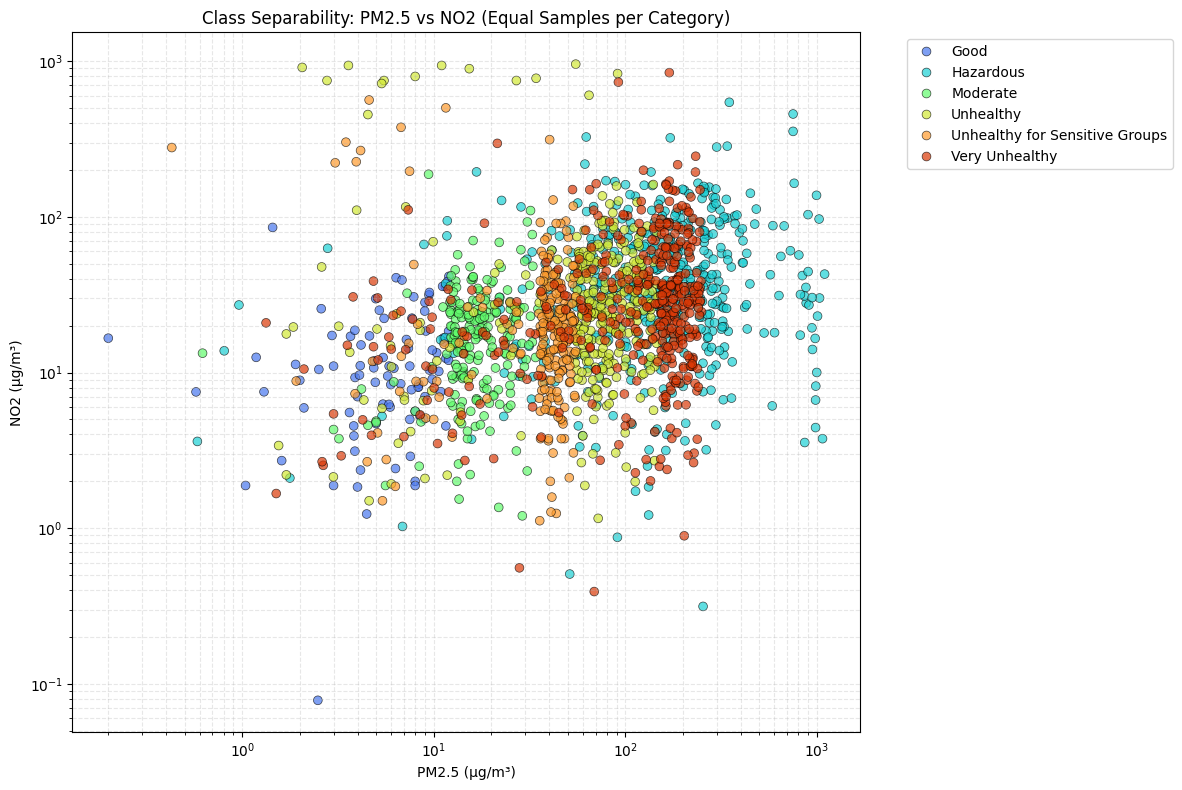

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STRATIFIED SAMPLING FOR CLEAR VISUALIZATION
# ---------------------------------------------------------

# 1. Take 500 random samples from EACH category
# (If a category has less than 500, it takes all of them)
stratified_sample = df_CTGAN.groupby('AQI_Category', observed=True).apply(
    lambda x: x.sample(n=min(len(x), 500), random_state=42)
).reset_index(drop=True)

# 2. Plot the balanced data
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=stratified_sample,
    x='PM2.5 (µg/m³)',
    y='NO2 (µg/m³)',
    hue='AQI_Category',
    palette='turbo',  # 'turbo' gives very distinct high-contrast colors
    alpha=0.7,
    edgecolor='k',    # Adds a black border to dots for clarity
    s=40              # Slightly larger dots
)

plt.title('Class Separability: PM2.5 vs NO2 (Equal Samples per Category)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()

/tmp/ipython-input-3719438859.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


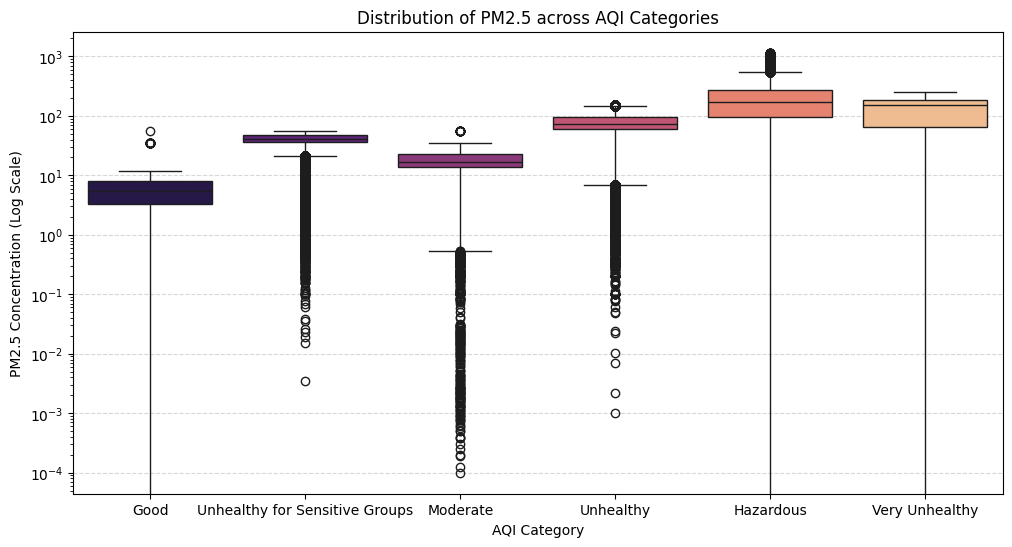

In [ ]:
plt.figure(figsize=(12, 6))

# We use PM2.5 as it's the main driver
sns.boxplot(
    data=df_CTGAN[df_CTGAN['AQI_Value'] > 0], # Filter bugs if any
    x='AQI_Category',
    y='PM2.5 (µg/m³)',
    palette='magma'
)

plt.title('Distribution of PM2.5 across AQI Categories')
plt.xlabel('AQI Category')
plt.ylabel('PM2.5 Concentration (Log Scale)')
plt.yscale('log') # Crucial for pollution data
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

/tmp/ipython-input-1399279941.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


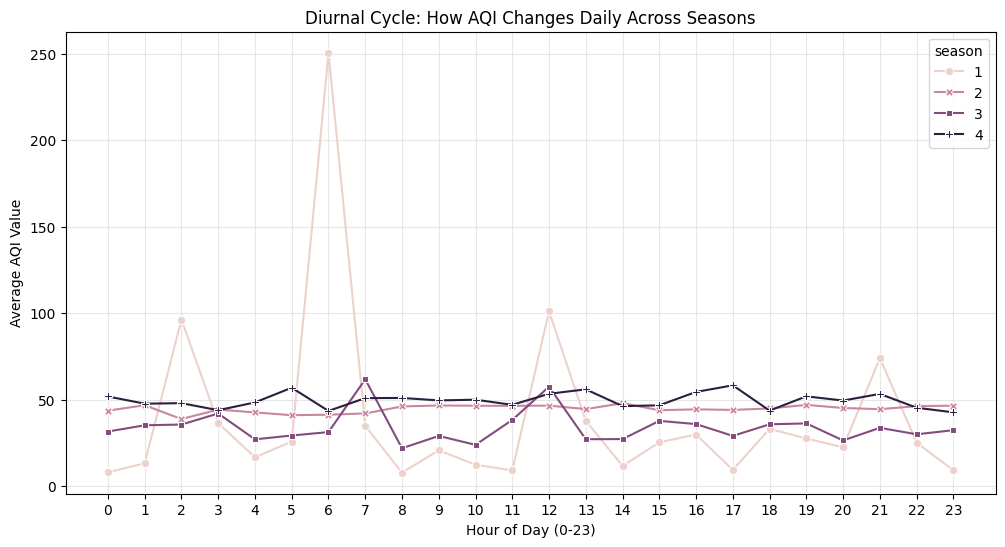

In [ ]:
plt.figure(figsize=(12, 6))

# Plot AQI trends over the day, split by Season
sns.lineplot(
    data=df_CTGAN.sample(50000), # Use a larger sample for smooth lines
    x='local_hour',
    y='AQI_Value',
    hue='season',
    style='season',
    markers=True,
    dashes=False,
    ci=None # Turn off confidence interval for speed, or set to 95
)

plt.title('Diurnal Cycle: How AQI Changes Daily Across Seasons')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average AQI Value')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

BUILDING THE ENSEMBLE MODEL

In [ ]:
# SPLITTING AND DEFINING X & y

df_CTGAN = df_CTGAN.sort_values(by=['local_time']).reset_index(drop=True)

features = [
    # Geography
    'latitude', 'longitude',
    # Pollutants
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)',
    # 24h Averages
    'PM2.5_24h_mean', 'PM10_24h_mean', 'NO2_24h_mean',
    'SO2_24h_mean', 'O3_24h_mean', 'CO_24h_mean',
    # Time Features
    'local_month', 'local_hour', 'local_day_of_week',
    'hour_sin', 'hour_cos', 'is_weekend', 'season', 'time_of_day'
]


print(f"Total Features Selected: {len(features)}")

# Define Target
target = 'AQI_Value'

#  Calculate Split (85% Train, 15% Test)
split_index = int(len(df_CTGAN) * 0.85)

# Create Train/Test Sets
X_train = df_CTGAN.iloc[:split_index][features]
y_train = df_CTGAN.iloc[:split_index][target]

X_test = df_CTGAN.iloc[split_index:][features]
y_test = df_CTGAN.iloc[split_index:][target]

print(f"Training Data (Past):   {X_train.shape}")
print(f"Testing Data (Future):  {X_test.shape}")

Total Features Selected: 22
Training Data (Past):   (5706651, 22)
Testing Data (Future):  (1007057, 22)


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# TRAIN MODEL 1 - LIGHTGBM

print("1. Initializing LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

print("2. Training (Fitting) on Past Data...")
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print("3. Predicting on Future Data...")
y_pred_lgb = lgb_model.predict(X_test)

# EVALUATION
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae = mean_absolute_error(y_test, y_pred_lgb)

print("\n--- LightGBM Performance ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE (Mean Absolute Error):      {mae:.2f}")

1. Initializing LightGBM...
2. Training (Fitting) on Past Data...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.619002 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3655
[LightGBM] [Info] Number of data points in the train set: 5706651, number of used features: 22
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 45.182753
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 5.05677	valid_0's l2: 25.571
[200]	valid_0's rmse: 4.37835	valid_0's l2: 19.1699
[300]	valid_0's rmse: 4.23165	valid_0's l2: 17.9069
[400]	valid_0's rmse: 4.12837	valid_0's l2: 17.0435
[500]	valid_0's rmse: 4.08019	valid_0's l2: 16.6479
[600]	valid_0's rmse: 4.04475	valid_0's l2: 1

In [ ]:
import xgboost as xgb

# TRAIN MODEL 2 - XGBOOST

print("1. Initializing XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

print("2. Training XGBoost (This might take slightly longer)...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("3. Predicting with XGBoost...")
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("\n--- XGBoost Performance ---")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE:  {mae_xgb:.2f}")

1. Initializing XGBoost...
2. Training XGBoost (This might take slightly longer)...
[0]	validation_0-rmse:39.86420
[100]	validation_0-rmse:4.38245
[200]	validation_0-rmse:4.31776
[300]	validation_0-rmse:4.32359
[400]	validation_0-rmse:4.33674
[500]	validation_0-rmse:4.34202
[600]	validation_0-rmse:4.34900
[700]	validation_0-rmse:4.34770
[800]	validation_0-rmse:4.35123
[900]	validation_0-rmse:4.35579
[999]	validation_0-rmse:4.35833
3. Predicting with XGBoost...

--- XGBoost Performance ---
RMSE: 4.36
MAE:  0.62


In [ ]:
# ENSEMBLE (THE VOTING REGRESSOR)

print("Averaging Predictions...")
final_predictions = (0.5 * y_pred_lgb) + (0.5 * y_pred_xgb)

# Evaluation
ensemble_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
ensemble_mae = mean_absolute_error(y_test, final_predictions)

print("\n=== FINAL ENSEMBLE RESULTS ===")
print(f"LightGBM RMSE: {rmse:.4f}")
print(f"XGBoost RMSE:  {rmse_xgb:.4f}")
print("-----------------------------")
print(f"ENSEMBLE RMSE: {ensemble_rmse:.4f}")
print(f"ENSEMBLE MAE:  {ensemble_mae:.4f}")

Averaging Predictions...

=== FINAL ENSEMBLE RESULTS ===
LightGBM RMSE: 3.9818
XGBoost RMSE:  4.3583
-----------------------------
ENSEMBLE RMSE: 3.7763
ENSEMBLE MAE:  0.6080


SHAP ANALYSIS

In [ ]:
import shap
print("1. Preparing SHAP Explainer...")
# TreeExplainer is optimized for LightGBM
explainer = shap.TreeExplainer(lgb_model)

print("2. Calculating SHAP values (Sampling 10000 rows)...")
X_shap_sample = X_test.sample(n=10000, random_state=42)
shap_values = explainer.shap_values(X_shap_sample)

1. Preparing SHAP Explainer...
2. Calculating SHAP values (Sampling 10000 rows)...


3. Generating Plot 1: Summary Plot...


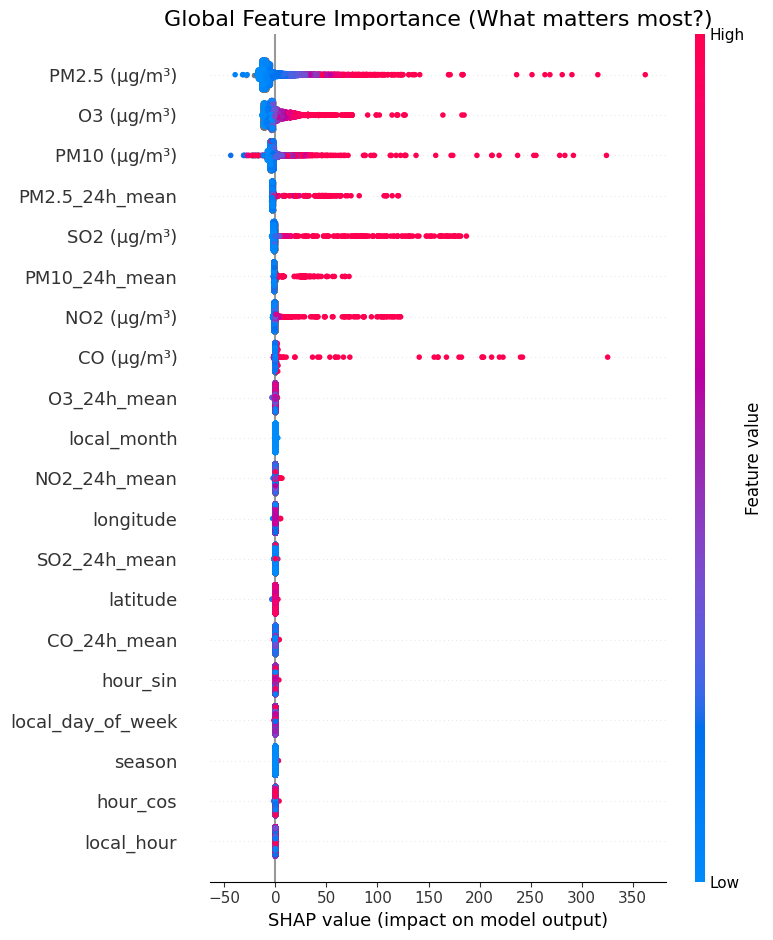

In [ ]:
# PLOT 1: SUMMARY PLOT
print("3. Generating Plot 1: Summary Plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title("Global Feature Importance (What matters most?)", fontsize=16)
plt.tight_layout()
plt.show()

4. Generating Plot 2: Category Bar Plot...


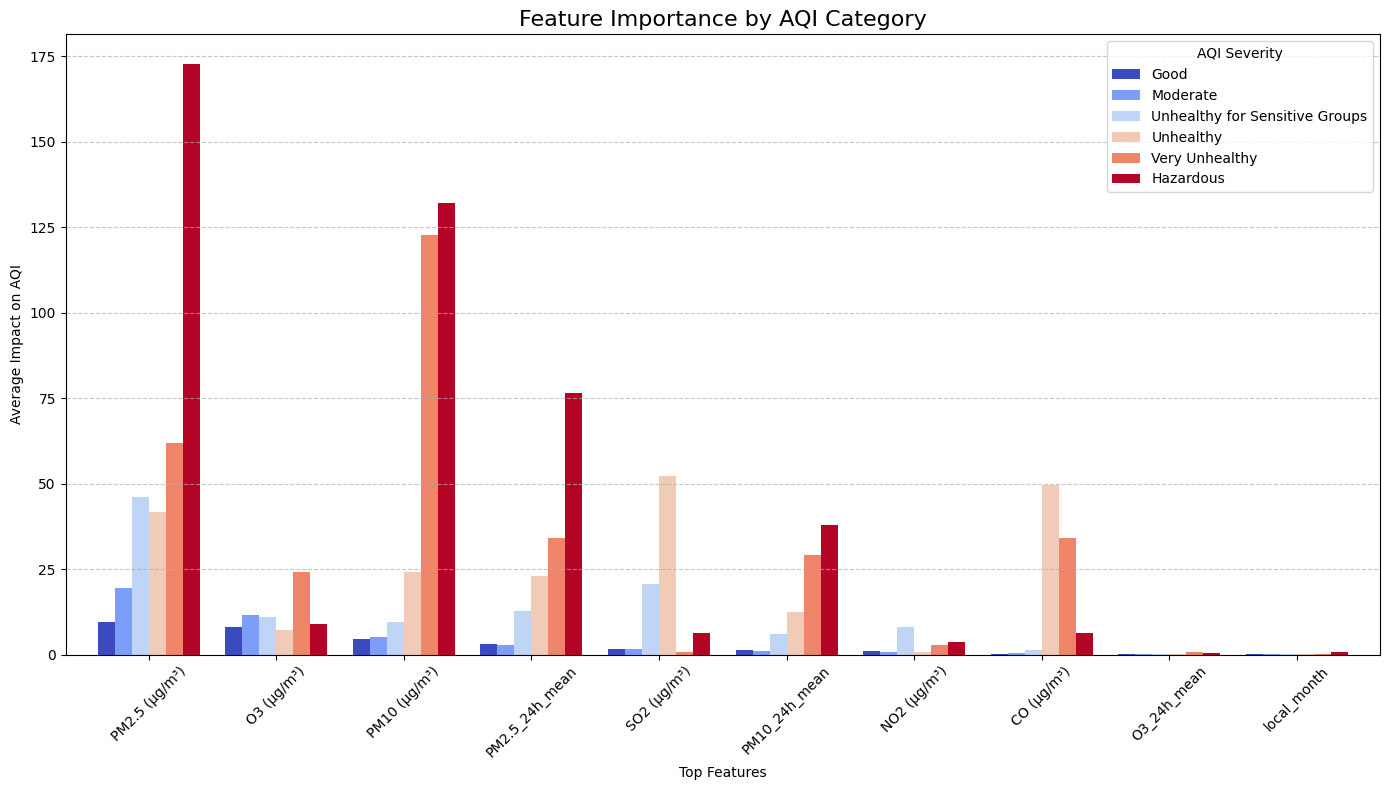

In [ ]:
# PLOT 2: AQI CATEGORY BAR PLOT
print(" Generating Plot 2: Category Bar Plot...")
# Create DataFrame of absolute SHAP impacts
df_shap = pd.DataFrame(np.abs(shap_values), columns=X_shap_sample.columns)

# Get predictions to categorize the sample
preds = lgb_model.predict(X_shap_sample)

# Binning logic (CPCB Standards)
bins = [0, 50, 100, 200, 300, 400, 5000]
labels = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy','Very Unhealthy','Hazardous']
df_shap['AQI_Category'] = pd.cut(preds, bins=bins, labels=labels)

# Find Top 5 features by impact
top_10_features = df_shap.drop(columns=['AQI_Category']).mean().sort_values(ascending=False).head(10).index

# Group by Category and Plot
plot_data = df_shap.groupby('AQI_Category', observed=False)[top_10_features].mean().T

ax = plot_data.plot(kind='bar', figsize=(14, 8), width=0.8, colormap='coolwarm')
plt.title("Feature Importance by AQI Category", fontsize=16)
plt.ylabel("Average Impact on AQI")
plt.xlabel("Top Features")
plt.legend(title="AQI Severity")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

5. Generating Plot 3: Dependence Subplots...


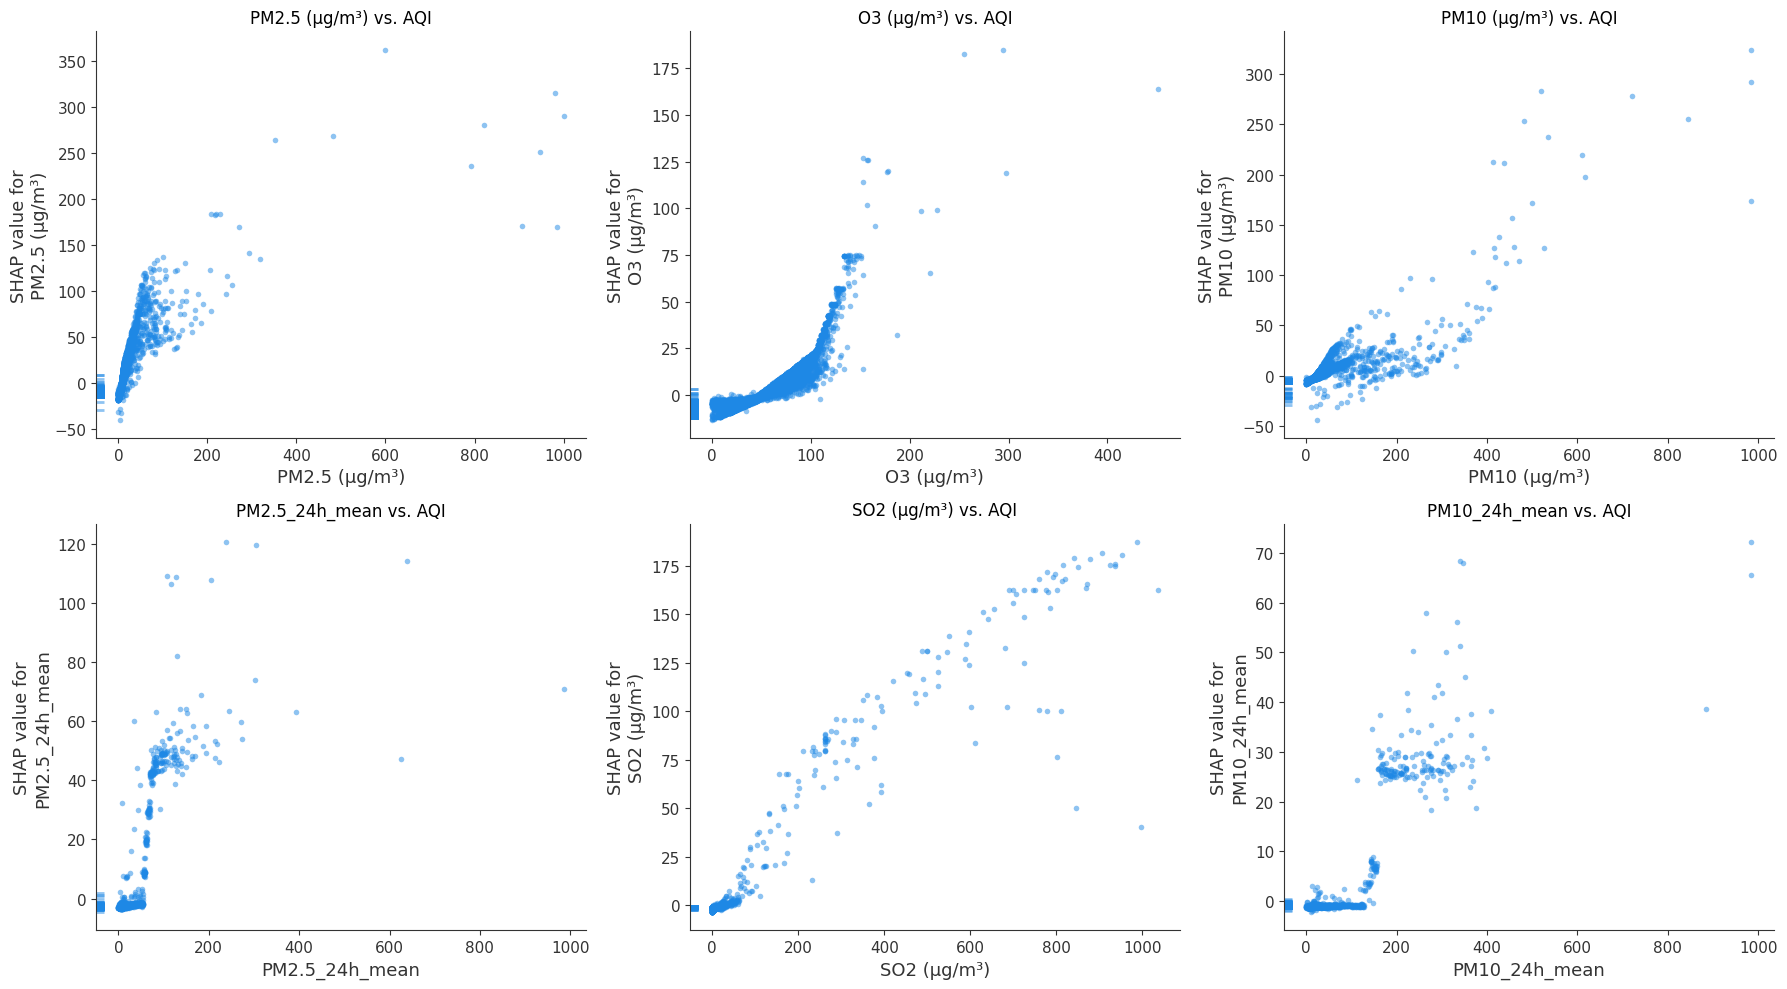

In [ ]:
import matplotlib.pyplot as plt

# Define the exact features you want to plot
features_to_plot = [
    'PM2.5 (µg/m³)',
    'O3 (µg/m³)',
    'PM10 (µg/m³)',
    'PM2.5_24h_mean',
    'SO2 (µg/m³)',
    'PM10_24h_mean'
]

print("5. Generating Plot 3: Dependence Subplots...")

#  Create a grid of subplots (2 rows, 3 columns = 6 plots)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

axes = axes.flatten()

# Loop through your features and draw each one in its assigned box
for i, feature in enumerate(features_to_plot):
    shap.dependence_plot(
        feature,
        shap_values,
        X_shap_sample,
        interaction_index=None,
        alpha=0.5,
        ax=axes[i],
        show=False
    )
    # Add a clean title to each subplot
    axes[i].set_title(f"{feature} vs. AQI", fontsize=12)

plt.tight_layout()
plt.show()

6. Generating Plot 4: Waterfall Plot (Single Prediction)...


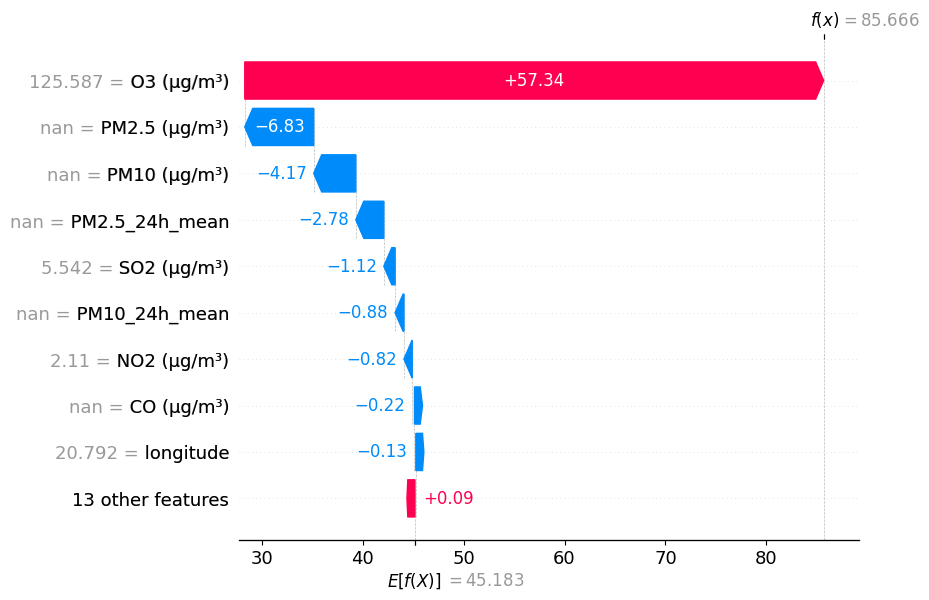

In [ ]:
#  PLOT 4: WATERFALL PLOT
print("6. Generating Plot 4: Waterfall Plot (Single Prediction)...")
shap_object = explainer(X_shap_sample)
shap.plots.waterfall(shap_object[0])

TESTING THE MODEL ON NEW DATASET

In [ ]:
test_data = pd.read_csv('/content/drive/MyDrive/Test_AQI.csv')
test_data.head()

,Unnamed: 0,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name,local_time,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,pollutant_fraction,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos
0,7036200,2022-05-20,NL,Veldhoven,Veldhoven-Europalaan,51.407400,5.393330,21.132933,26.190000,NaN,NaN,14.903334,NaN,3,Netherlands,2022-05-20 00:21:34+00:00,0,5,4,0,2,4,0.500000,15.483969,32.110000,NaN,NaN,47.642708,NaN,0.000000,1.000000
1,7272784,2022-05-20,ZA,Bojanala Platinum,Xanadu-NAQI,-25.648893,27.238081,40.581665,38.817333,17.367440,8.604954,18.102560,651.88666,6,South Africa,2022-05-20 01:48:57+00:00,1,5,4,0,4,4,1.000000,20.696735,20.821285,13.346512,9.264193,32.313050,365.72412,0.258819,0.965926
2,4632758,2022-05-20,CL,Las Condes,Las Condes,-33.408455,-70.567150,51.333332,95.666664,NaN,NaN,NaN,NaN,2,Chile - SINCA,2022-05-19 19:17:44+00:00,19,5,3,0,4,3,0.333333,60.875000,125.916664,NaN,NaN,NaN,NaN,-0.965926,0.258819
3,4357731,2022-05-20,TH,Kanchanaburi,Kanchanaburi Meteorological Station,8.000000,14.022376,5.333334,19.000000,0.626667,0.000000,NaN,NaN,4,Air4Thai,2022-05-20 00:56:05+00:00,0,5,4,0,2,4,0.666667,6.562500,19.652779,0.026111,0.000000,NaN,NaN,0.000000,1.000000
4,84126,2022-05-20,AT,Niederösterreich,AT30403,48.392223,16.522667,NaN,NaN,4.308277,NaN,112.665474,NaN,2,EEA Austria,2022-05-20 01:06:05+00:00,1,5,4,0,2,4,0.333333,NaN,NaN,3.871215,NaN,107.914530,NaN,0.258819,0.965926


In [ ]:
test_data = test_data.drop(columns=['Unnamed: 0'])


In [ ]:
test_data.columns

Index(['timestamp', 'country', 'region_name', 'station_name', 'latitude',
       'longitude', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
       'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'pollutant_count',
       'source_name', 'local_time', 'local_hour', 'local_month',
       'local_day_of_week', 'is_weekend', 'season', 'time_of_day',
       'pollutant_fraction', 'PM2.5_24h_mean', 'PM10_24h_mean', 'NO2_24h_mean',
       'SO2_24h_mean', 'O3_24h_mean', 'CO_24h_mean', 'hour_sin', 'hour_cos'],
      dtype='object')

In [ ]:
X_new = test_data[X_train.columns]

print(f"Aligning columns... Model expects {X_train.shape[1]} features.")

Aligning columns... Model expects 22 features.


In [ ]:
pred_lgb = lgb_model.predict(X_new)
pred_xgb = xgb_model.predict(X_new)

# Weighted Average (Ensemble)
final_preds = (0.5 * pred_lgb) + (0.5 * pred_xgb)

# Save Prediction to the DataFrame
test_data['Predicted_AQI'] = final_preds

In [ ]:
print("2. Assigning Weighted Confidence Scores...")

# Check availability of pollutants
has_pm25 = test_data['PM2.5 (µg/m³)'].notna()
has_pm10 = test_data['PM10 (µg/m³)'].notna()
has_o3   = test_data['O3 (µg/m³)'].notna()
has_no2  = test_data['NO2 (µg/m³)'].notna()
has_so2  = test_data['SO2 (µg/m³)'].notna()
has_co   = test_data['CO (µg/m³)'].notna()

# Initialize Score
test_data['AQI_Confidence'] = 0

# Base Score Logic
test_data.loc[has_pm25, 'AQI_Confidence'] = 75
test_data.loc[has_pm10 & ~has_pm25, 'AQI_Confidence'] = 60
test_data.loc[~has_pm10 & ~has_pm25, 'AQI_Confidence'] = 35

# Bonus Points
test_data.loc[has_pm10, 'AQI_Confidence'] += 10
test_data.loc[has_o3, 'AQI_Confidence'] += 5

# Minor Gas Bonus
minor_gas_count = (has_no2.astype(int) + has_so2.astype(int) + has_co.astype(int))
test_data['AQI_Confidence'] += (minor_gas_count * 4)

# Cleanup (Clip at 100)
test_data['AQI_Confidence'] = test_data['AQI_Confidence'].clip(upper=100)
test_data.loc[test_data['Predicted_AQI'].isna(), 'AQI_Confidence'] = 0


2. Assigning Weighted Confidence Scores...


In [ ]:
# Define Bins (Your Custom Standard)
bins = [-1, 50, 100, 150, 200, 300, float('inf')]

# Define Labels
labels = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]

# Apply to the PREDICTED AQI
test_data['AQI_Category'] = pd.cut(test_data['Predicted_AQI'], bins=bins, labels=labels)

In [ ]:
test_data['Predicted_AQI'] = test_data['Predicted_AQI'].round(2)

In [ ]:
test_data.head()

,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name,local_time,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,pollutant_fraction,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos,Predicted_AQI,AQI_Confidence,AQI_Category
0,2022-05-20,NL,Veldhoven,Veldhoven-Europalaan,51.407400,5.393330,21.132933,26.190000,NaN,NaN,14.903334,NaN,3,Netherlands,2022-05-20 00:21:34+00:00,0,5,4,0,2,4,0.500000,15.483969,32.110000,NaN,NaN,47.642708,NaN,0.000000,1.000000,69.88,90,Moderate
1,2022-05-20,ZA,Bojanala Platinum,Xanadu-NAQI,-25.648893,27.238081,40.581665,38.817333,17.367440,8.604954,18.102560,651.88666,6,South Africa,2022-05-20 01:48:57+00:00,1,5,4,0,4,4,1.000000,20.696735,20.821285,13.346512,9.264193,32.313050,365.72412,0.258819,0.965926,113.32,100,Unhealthy for Sensitive Groups
2,2022-05-20,CL,Las Condes,Las Condes,-33.408455,-70.567150,51.333332,95.666664,NaN,NaN,NaN,NaN,2,Chile - SINCA,2022-05-19 19:17:44+00:00,19,5,3,0,4,3,0.333333,60.875000,125.916664,NaN,NaN,NaN,NaN,-0.965926,0.258819,139.73,85,Unhealthy for Sensitive Groups
3,2022-05-20,TH,Kanchanaburi,Kanchanaburi Meteorological Station,8.000000,14.022376,5.333334,19.000000,0.626667,0.000000,NaN,NaN,4,Air4Thai,2022-05-20 00:56:05+00:00,0,5,4,0,2,4,0.666667,6.562500,19.652779,0.026111,0.000000,NaN,NaN,0.000000,1.000000,22.91,93,Good
4,2022-05-20,AT,Niederösterreich,AT30403,48.392223,16.522667,NaN,NaN,4.308277,NaN,112.665474,NaN,2,EEA Austria,2022-05-20 01:06:05+00:00,1,5,4,0,2,4,0.333333,NaN,NaN,3.871215,NaN,107.914530,NaN,0.258819,0.965926,61.98,44,Moderate
